In [2]:
#BIOMATH EX 2 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [4]:
#Params 
s0 = 5
e0 = 0.001

k_1 = 50
k1 = 102
k2 = 1
k_3 = 50
k3 = 26

#Equations 

def substrate_inibition (y,t):
    s, c1, c2 = y
    dsdt = -k1*s*(e0-c1-c2) +c1*(k_1 - k3*s) + k_3*c2
    dc1dt = k1*s*(e0 -c1-c2) - c1* (k_1 + k2+ k3*s) + k_3*c2
    dc2dt = k3*c1*s - k_3*c2

    return [dsdt, dc1dt, dc2dt]

t = np.linspace(0, 1, 100)

#Initial condition !!

y0 = [s0, 0, 0]
solution = odeint (substrate_inibition, y0, t,  rtol=5.e-13, atol=1.e-13* np.ones(3))
#solution 

comp1 = solution[:, 1]
comp2 = solution[:, 2]
sub = solution [:, 0]

In [5]:
#Analysis of the C1-formation-Rate 
#quasi-stationary approximation


km = ((k_1 + k2)/ k1)
ki = k_3/k3

def qs_approx (s,t):
    c1 = (k1*s*e0*ki)/ (ki*k1*s + k1*s**2 + k_1*ki + k2*s )
    c2 = (k1*s**2 * e0) /(ki*k1*s + k1*s**2 + k_1*ki + k2*s )
    dsdt = -k1*s*(e0 - c1 - c2) +c1*(k_1 - k3*s) + k_3*c2

    return np.array([dsdt]).ravel()


t = np.linspace(0, 1, 100)


#solution 
solution_app = odeint (qs_approx, s0, t).flatten()

s = solution_app
c1_app = (k1*s*e0*ki)/ (ki*k1*s + k1*s**2 + k_1*ki + k2*s )
c2_app = (k1*s**2 * e0) /(ki*k1*s + k1*s**2 + k_1*ki + k2*s )


C:\Users\bulga\AppData\Local\Temp\ipykernel_16308\1683061816.py:4: RuntimeWarning: divide by zero encountered in divide
  err_C1 = np.abs(comp1 - c1_app) / np.abs(comp1)
C:\Users\bulga\AppData\Local\Temp\ipykernel_16308\1683061816.py:5: RuntimeWarning: divide by zero encountered in divide
  err_C2 = np.abs(comp2 - c2_app) / np.abs(comp2)


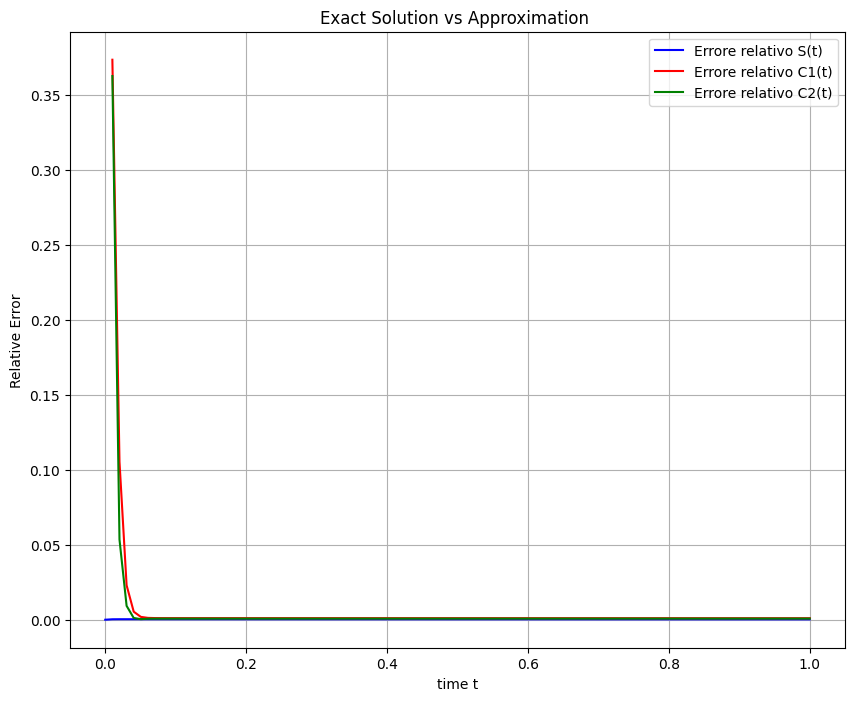

In [9]:
#compute the relative errors 
plt.figure(figsize=(10,8 ))
err_S = np.abs(sub - s) / np.abs(sub)
err_C1 = np.abs(comp1 - c1_app) / np.abs(comp1)
err_C2 = np.abs(comp2 - c2_app) / np.abs(comp2)

plt.plot(t, err_S, label='Errore relativo S(t)', color='b')  # Aggiunta della label per err_S
plt.plot(t, err_C1, label='Errore relativo C1(t)', color='r')
plt.plot(t, err_C2, label='Errore relativo C2(t)', color='g')


plt.xlabel('time t')
plt.ylabel('Relative Error')
plt.title('Exact Solution vs Approximation ')

plt.legend()
plt.grid(True)
plt.show()


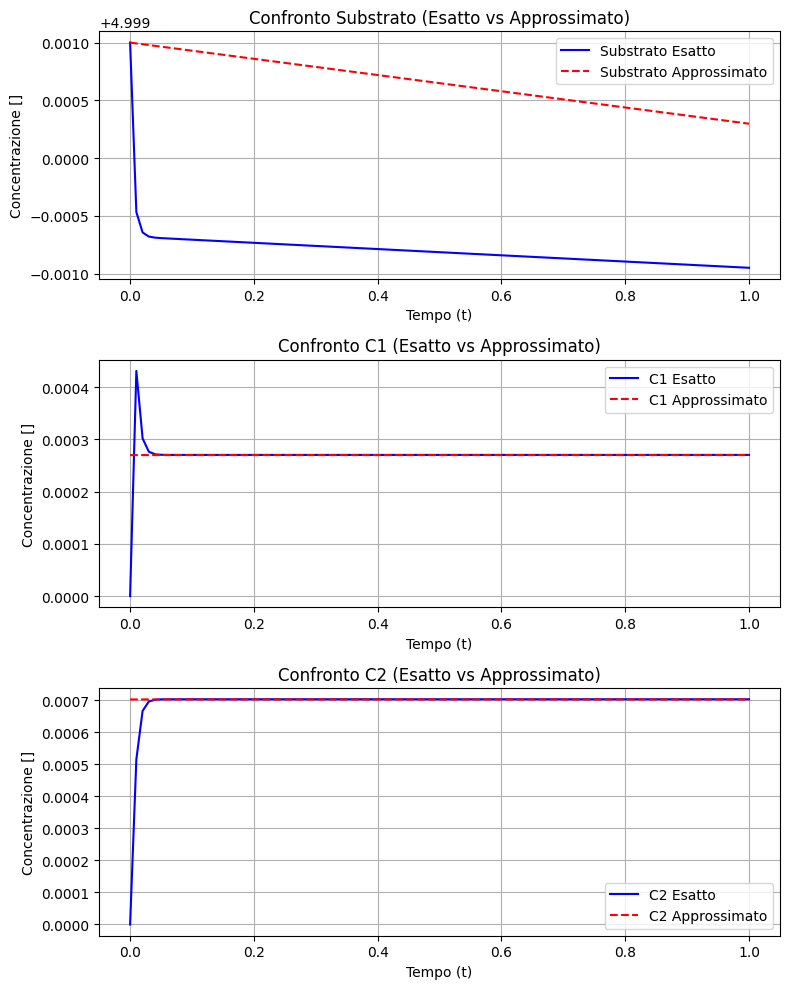

In [7]:
# Creazione dei sottografici
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

# Sottografico 1: Confronto del Substrato (esatto vs approssimato)
axs[0].plot(t, sub, label='Substrato Esatto', color='b')
axs[0].plot(t, solution_app, label='Substrato Approssimato', color='r', linestyle='--')
axs[0].set_xlabel("Tempo (t)")
axs[0].set_ylabel('Concentrazione []')
axs[0].set_title('Confronto Substrato (Esatto vs Approssimato)')
axs[0].legend()
axs[0].grid(True)

# Sottografico 2: Confronto di C1 (esatto vs approssimato)
axs[1].plot(t, comp1, label="C1 Esatto", color='b')
axs[1].plot(t, c1_app, label="C1 Approssimato", color='r', linestyle='--')
axs[1].set_xlabel("Tempo (t)")
axs[1].set_ylabel('Concentrazione []')
axs[1].set_title('Confronto C1 (Esatto vs Approssimato)')
axs[1].legend()
axs[1].grid(True)

# Sottografico 3: Confronto di C2 (esatto vs approssimato)
axs[2].plot(t, comp2, label="C2 Esatto", color='b')
axs[2].plot(t, c2_app, label="C2 Approssimato", color='r', linestyle='--')
axs[2].set_xlabel("Tempo (t)")
axs[2].set_ylabel('Concentrazione []')
axs[2].set_title('Confronto C2 (Esatto vs Approssimato)')
axs[2].legend()
axs[2].grid(True)

# Migliora il layout per evitare sovrapposizioni
plt.tight_layout()

# Mostra tutti i sottografici
plt.show()